==============================================================================
  ThirdEye Labs — "The Mathematics of Intelligence"
  LAB 0.2 — Decode Math Notation: Sigma and Pi (Hands-On in Python)
==============================================================================
Pairs with concept episode S0.2 (Part 1: The Essentials). We turn the "scary"
symbols into code: a sum (Sigma) is a for-loop that adds, a product (Pi) is a
for-loop that multiplies, subscripts are just list indices. We build each by
hand, then collapse it to a one-line NumPy version and prove they match.

WHY THIS LAB: a neuron's output is literally Sigma w_i x_i + b. If you can write
that sum as a loop and as one NumPy line, you can read every equation that
follows in this series.

------------------------------------------------------------------------------
SETUP
    pip install numpy matplotlib
Run top-to-bottom:
    python lab_0_2_notation.py
Or paste each numbered SECTION into its own Jupyter cell.
------------------------------------------------------------------------------

In [70]:
import numpy as np
import matplotlib.pyplot as plt

# Deterministic: viewers get exactly what the video shows.
np.random.seed(7)

# House style so the plots match the channel's dark look.
plt.rcParams.update({
    "figure.facecolor": "#0b0e14",
    "axes.facecolor":   "#0b0e14",
    "axes.edgecolor":   "#e6edf3",
    "axes.labelcolor":  "#e6edf3",
    "text.color":       "#e6edf3",
    "xtick.color":      "#e6edf3",
    "ytick.color":      "#e6edf3",
    "axes.grid":        True,
    "grid.color":       "#243042",
    "font.size":        12,
})
GREEN, RED, BLUE, YELLOW, PURPLE = "#3fb950", "#f85149", "#58a6ff", "#f0b429", "#bc8cff"

In [71]:
# =============================================================================
# SECTION 1 — SIGMA (Σ) is a for-loop that ADDS
# Math:  Σ_{i=1}^{n} a_i   means "add up a_1, a_2, ... a_n"
# WHY: the single most common symbol in ML. It hides a loop you already know.
# =============================================================================
a = [2, 5, 1, 8, 3]   # subscripts a_1..a_5 are just list positions a[0]..a[4]

# --- BY HAND: the loop the symbol stands for ---
total = 0
for i in range(len(a)):     # i walks the subscript
    total += a[i]           # the "+=" is the Sigma doing its job
print("SECTION 1 — Sigma (sum)")
print("  by-hand loop : Σ a_i =", total)

# --- ONE-LINER: the same thing in NumPy ---
print("  numpy        : np.sum(a) =", int(np.sum(a)))
assert total == np.sum(a)   # they MUST match

SECTION 1 — Sigma (sum)
  by-hand loop : Σ a_i = 19
  numpy        : np.sum(a) = 19


In [72]:
# =============================================================================
# SECTION 2 — PI (Π) is a for-loop that MULTIPLIES
# Math:  Π_{i=1}^{n} p_i   means "multiply p_1 * p_2 * ... * p_n"
# WHY: shows up in probability (joint likelihood) all the time.
# =============================================================================
p = [0.5, 0.8, 0.9, 0.4]    # e.g. four probabilities

# --- BY HAND ---
product = 1                 # start at 1 (the identity for multiplication)
for i in range(len(p)):
    product *= p[i]
print("\nSECTION 2 — Pi (product)")
print(f"  by-hand loop : Π p_i = {product:.4f}")
print(f"  numpy        : np.prod(p) = {np.prod(p):.4f}")
assert np.isclose(product, np.prod(p))




SECTION 2 — Pi (product)
  by-hand loop : Π p_i = 0.1440
  numpy        : np.prod(p) = 0.1440


In [73]:
# =============================================================================
# SECTION 3 — THE WEIGHTED SUM: Σ_i w_i x_i  (this IS a neuron)
# WHY: the heart of every neural network layer. Two subscripted lists, paired up.
# =============================================================================
w = [0.2, -0.5, 1.0, 0.7]   # weights  w_i
x = [1.0,  2.0, 0.5, 3.0]   # inputs   x_i

# --- BY HAND: pair each w_i with its x_i, multiply, then add ---
z = 0.0
for i in range(len(w)):
    z += w[i] * x[i]        # Σ_i w_i x_i, term by term
b = 0.1                     # a bias, added once at the end
z_plus_b = z + b
print("\nSECTION 3 — weighted sum (a neuron)")
print(f"  by-hand : Σ w_i x_i = {z:.2f},   + b = {z_plus_b:.2f}")

# --- ONE-LINER: the dot product is exactly this sum ---
z_np = np.dot(w, x) + b
print(f"  numpy   : np.dot(w, x) + b = {z_np:.2f}")
assert np.isclose(z_plus_b, z_np)
print('  Read it aloud: "z is the sum over i of w-i times x-i, plus b."')




SECTION 3 — weighted sum (a neuron)
  by-hand : Σ w_i x_i = 1.80,   + b = 1.90
  numpy   : np.dot(w, x) + b = 1.90
  Read it aloud: "z is the sum over i of w-i times x-i, plus b."


In [74]:

# =============================================================================
# SECTION 4 — SUBSCRIPTS vs SUPERSCRIPTS
# x_i      = the i-th element (an index)
# x^(l)    = a quantity at layer l (NOT an exponent — note the parentheses)
# x ** 2   = an actual power
# WHY: confusing these is the #1 notation mistake. Code makes the difference obvious.
# =============================================================================
X = np.array([[1, 2, 3],     # layer 0 activations (a^(0))
              [4, 5, 6],      # layer 1 activations (a^(1))
              [7, 8, 9]])     # layer 2 activations (a^(2))
print("\nSECTION 4 — subscripts vs superscripts")
print("  x_2 (index, 3rd element of row 0):", X[0, 2])   # subscript = index
print("  a^(1) (layer 1, a whole row)     :", X[1])      # superscript-in-parens = layer
print("  x ** 2 (a real power)            :", 3 ** 2)    # actual exponent




SECTION 4 — subscripts vs superscripts
  x_2 (index, 3rd element of row 0): 3
  a^(1) (layer 1, a whole row)     : [4 5 6]
  x ** 2 (a real power)            : 9



SECTION 6 — saved 01_sigma_unrolled.png


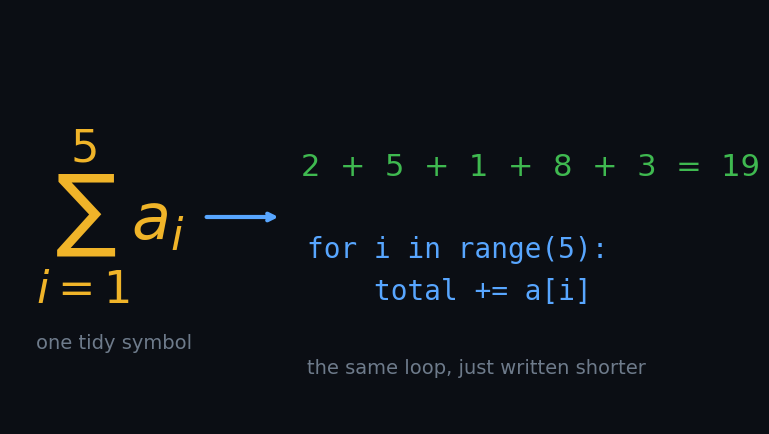

In [75]:

# =============================================================================
# SECTION 6 — VISUALIZE: a Sigma "unrolling" into a stack of + terms
# WHY: the signature visual, as a saved figure you can show on screen.
# =============================================================================
terms = a                         # reuse [2,5,1,8,3]
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.axis("off")
# left: the compact symbol
ax.text(0.04, 0.5, r"$\sum_{i=1}^{5} a_i$", fontsize=46, color=YELLOW, va="center")
ax.text(0.04, 0.18, "one tidy symbol", fontsize=14, color="#6e7b8b")
# arrow
ax.annotate("", xy=(0.42, 0.5), xytext=(0.30, 0.5),
            arrowprops=dict(arrowstyle="->", color=BLUE, lw=3))
# right: the unrolled stack of additions
unrolled = "  +  ".join(str(t) for t in terms) + f"  =  {sum(terms)}"
ax.text(0.45, 0.62, unrolled, fontsize=22, color=GREEN, va="center")
ax.text(0.46, 0.40, "for i in range(5):", fontsize=20, color=BLUE, family="monospace")
ax.text(0.46, 0.30, "    total += a[i]", fontsize=20, color=BLUE, family="monospace")
ax.text(0.46, 0.12, "the same loop, just written shorter", fontsize=14, color="#6e7b8b")
fig.tight_layout(); fig.savefig("01_sigma_unrolled.png", dpi=120)
print("\nSECTION 6 — saved 01_sigma_unrolled.png")



In [76]:

# =============================================================================
# SECTION 5 — THE "GRAMMAR" SYMBOLS as plain Python
# These are just words: in / for-all / there-exists / approx / proportional.
# =============================================================================
s = {1, 2, 3, 4}
print("\nSECTION 5 — grammar words")
print("  3 ∈ s      (in)            ->", 3 in s)
print("  ∀ even?    (for all)       ->", all(n % 2 == 0 for n in s))
print("  ∃ even?    (there exists)  ->", any(n % 2 == 0 for n in s))
print("  ≈ approx   (close to)      ->", np.isclose(0.1 + 0.2, 0.3))
# ∝ proportional: y ∝ x means y = k*x for some constant k
k = 3.0
print("  ∝ propto   (y = k x)       -> y =", k * np.array([1, 2, 3]))




SECTION 5 — grammar words
  3 ∈ s      (in)            -> True
  ∀ even?    (for all)       -> False
  ∃ even?    (there exists)  -> True
  ≈ approx   (close to)      -> True
  ∝ propto   (y = k x)       -> y = [3. 6. 9.]



SECTION 7 — a neuron scoring 3 samples
  by-hand loop : [1.38 2.58 2.7 ]
  numpy matrix : [1.38 2.58 2.7 ]
  saved 02_neuron_scores.png


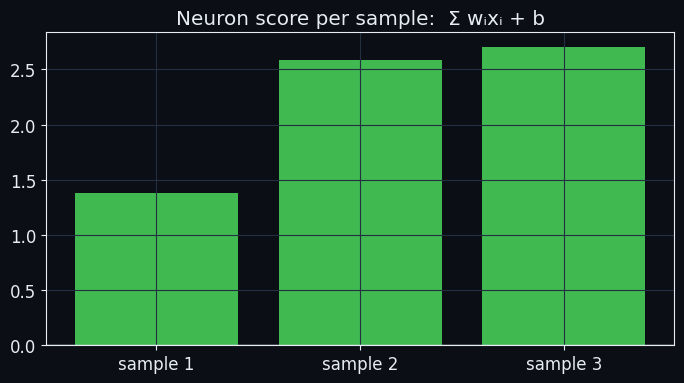

In [77]:

# =============================================================================
# SECTION 7 — A TINY REAL DATASET: a neuron scores 3 flowers
# Dataset: 3 hand-made samples (petal length, petal width) — iris-style, tiny.
# WHY: shows Σ w_i x_i computed across real rows, all at once with a matrix.
# =============================================================================
# features per sample: [petal_length, petal_width]
samples = np.array([[1.4, 0.2],    # sample 1
                    [4.7, 1.4],    # sample 2
                    [5.9, 2.1]])   # sample 3
weights = np.array([0.8, -1.2])    # the neuron's weights
bias = 0.5

# --- BY HAND: loop over each sample, compute Σ w_i x_i + b ---
scores_loop = []
for row in samples:
    s_ = 0.0
    for i in range(len(weights)):
        s_ += weights[i] * row[i]
    scores_loop.append(s_ + bias)
scores_loop = np.array(scores_loop)

# --- ONE-LINER: a matrix-vector product does ALL samples at once ---
scores_np = samples @ weights + bias    # @ is matmul; this is many Sigmas in parallel

print("\nSECTION 7 — a neuron scoring 3 samples")
print("  by-hand loop :", np.round(scores_loop, 3))
print("  numpy matrix :", np.round(scores_np, 3))
assert np.allclose(scores_loop, scores_np)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([f"sample {i+1}" for i in range(3)], scores_np,
       color=[GREEN if v >= 0 else RED for v in scores_np])
ax.axhline(0, color="#e6edf3", lw=1)
ax.set_title("Neuron score per sample:  Σ wᵢxᵢ + b")
fig.tight_layout(); fig.savefig("02_neuron_scores.png", dpi=120)
print("  saved 02_neuron_scores.png")


In [78]:

# =============================================================================
# SECTION 8 — BREAK IT ON PURPOSE: the off-by-one / wrong-start-value trap
# WHY (retention): the most common Sigma/Pi bugs are (a) starting a SUM at 1
# instead of 0, and (b) starting a PRODUCT at 0 instead of 1. Watch them fail.
# =============================================================================
nums = [2, 5, 1, 8, 3]

# WRONG: sum started at 1 -> every total is off by exactly 1
wrong_sum = 1
for v in nums:
    wrong_sum += v

# WRONG: product started at 0 -> everything collapses to 0
wrong_prod = 0
for v in nums:
    wrong_prod *= v

print("\nSECTION 8 — break it on purpose")
print(f"  sum started at 1 (WRONG)  -> {wrong_sum}   (should be {sum(nums)})")
print(f"  product started at 0 (WRONG) -> {wrong_prod}   (collapses to zero!)")

# FIX: a sum starts at 0, a product starts at 1 (their 'identity' values)
right_sum, right_prod = 0, 1
for v in nums:
    right_sum += v
    right_prod *= v
print(f"  FIX: sum starts at 0 -> {right_sum},  product starts at 1 -> {right_prod}")
print("  Lesson: a sum's identity is 0; a product's identity is 1.")

print("\nDone. Every symbol here was just a loop in disguise.")
# plt.show()  # uncomment when running interactively


SECTION 8 — break it on purpose
  sum started at 1 (WRONG)  -> 20   (should be 19)
  product started at 0 (WRONG) -> 0   (collapses to zero!)
  FIX: sum starts at 0 -> 19,  product starts at 1 -> 240
  Lesson: a sum's identity is 0; a product's identity is 1.

Done. Every symbol here was just a loop in disguise.
